# Tennis Betting Market Analysis
**Can our model find edge against the bookmaker?**

This notebook takes the trained models from `trytennisagain.ipynb` and compares their predicted probabilities against bookmaker implied probabilities on the Aus Open 2025 test set.

The framing is deliberately quant research-style: we treat the bookmaker as an efficient market and ask whether our model generates systematic *edge* — mispricings we can exploit.

**Requires:** `trytennisagain.ipynb` to have been run first (models and test data in memory), plus `atp_tennis_2025.csv` in `../data/`.

In [13]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from scipy.stats import norm
from sklearn.metrics import roc_auc_score, brier_score_loss

logistic_regression = joblib.load('../models/logistic_regression.pkl')
neural_network      = joblib.load('../models/neural_network.pkl')
svm                 = joblib.load('../models/svm.pkl')
xgboost             = joblib.load('../models/xgboost.pkl')
naive_bayes         = joblib.load('../models/naive_bayes.pkl')

X_train, X_test, y_train, y_test = joblib.load('../models/data_splits.pkl')

models = {
    'Logistic Regression': logistic_regression,
    'Neural Network':      neural_network,
    'SVM':                 svm,
    'XGBoost':             xgboost,
    'Naive Bayes':         naive_bayes,
}
print('All models and test data loaded.')


All models and test data loaded.


## 1. Merge betting odds onto the test set

In [14]:
odds_raw = pd.read_csv('../data/atp_tennis_2025.csv')
ao_odds  = odds_raw[odds_raw['Tournament'] == 'Australian Open'].copy()
ao_odds

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
0,Australian Open,2025-01-12,Grand Slam,Outdoor,Hard,1st Round,5,Jasika O.,Gaston H.,Gaston H.,179,81,323,703,3.20,1.36,2-6 6-3 2-6 2-6
1,Australian Open,2025-01-12,Grand Slam,Outdoor,Hard,1st Round,5,Fils A.,Virtanen O.,Fils A.,21,93,2280,627,1.13,6.00,3-6 7-6 6-4 6-4
2,Australian Open,2025-01-12,Grand Slam,Outdoor,Hard,1st Round,5,Monteiro T.,Nishikori K.,Nishikori K.,105,76,566,743,4.50,1.20,6-4 7-6 5-7 2-6 3-6
3,Australian Open,2025-01-12,Grand Slam,Outdoor,Hard,1st Round,5,Ruud C.,Munar J.,Ruud C.,6,62,4210,922,1.17,5.00,6-3 1-6 7-5 2-6 6-1
4,Australian Open,2025-01-12,Grand Slam,Outdoor,Hard,1st Round,5,Bu Y.,Habib H.,Habib H.,67,219,784,264,1.36,3.20,6-7 4-6 6-7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,Australian Open,2025-01-21,Grand Slam,Outdoor,Hard,Quarterfinals,5,Djokovic N.,Alcaraz C.,Djokovic N.,7,3,3900,7010,2.50,1.53,4-6 6-4 6-3 6-4
112,Australian Open,2025-01-22,Grand Slam,Outdoor,Hard,Quarterfinals,5,Sonego L.,Shelton B.,Shelton B.,55,20,1026,2280,3.20,1.36,4-6 5-7 6-4 6-7
113,Australian Open,2025-01-22,Grand Slam,Outdoor,Hard,Quarterfinals,5,Sinner J.,De Minaur A.,Sinner J.,1,8,11830,3535,1.17,5.00,6-3 6-2 6-1
114,Australian Open,2025-01-24,Grand Slam,Outdoor,Hard,Semifinals,5,Shelton B.,Sinner J.,Sinner J.,20,1,2280,11830,11.00,1.05,6-7 2-6 2-6


In [15]:
# Match rows using unordered (rank1, rank2) pair — unique per match
ao_odds['rank_pair'] = ao_odds.apply(
    lambda r: tuple(sorted([int(r['Rank_1']), int(r['Rank_2'])])), axis=1)
aos['rank_pair'] = aos.apply(
    lambda r: tuple(sorted([int(r['p1_rank']), int(r['p2_rank'])])), axis=1)

merged = aos.merge(
    ao_odds[['rank_pair', 'Rank_1', 'Rank_2', 'Odd_1', 'Odd_2']],
    on='rank_pair', how='left')

# Orient odds to the aos perspective (p1 in aos may not be Player_1 in odds)
merged['p1_is_rank1'] = merged['p1_rank'] == merged['Rank_1']
merged['p1_odd'] = merged.apply(
    lambda r: r['Odd_1'] if r['p1_is_rank1'] else r['Odd_2'], axis=1)
merged['p2_odd'] = merged.apply(
    lambda r: r['Odd_2'] if r['p1_is_rank1'] else r['Odd_1'], axis=1)
merged

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,p1_id,p1_seed,p1_entry,...,p2_rank_points,RESULT,rank_pair,Rank_1,Rank_2,Odd_1,Odd_2,p1_is_rank1,p1_odd,p2_odd
0,AUSTRALIAN_OPEN_2025,0.0,Hard,128,0.0,0.0,0.0,117357,0.0,0.0,...,703,0,"(81, 179)",179,81,3.20,1.36,True,3.20,1.36
1,AUSTRALIAN_OPEN_2025,0.0,Hard,128,0.0,0.0,0.0,202261,0.0,0.0,...,2280,0,"(21, 93)",21,93,1.13,6.00,False,6.00,1.13
2,AUSTRALIAN_OPEN_2025,0.0,Hard,128,0.0,0.0,0.0,105453,0.0,0.0,...,566,1,"(76, 105)",105,76,4.50,1.20,False,1.20,4.50
3,AUSTRALIAN_OPEN_2025,0.0,Hard,128,0.0,0.0,0.0,134770,0.0,0.0,...,922,1,"(6, 62)",6,62,1.17,5.00,True,1.17,5.00
4,AUSTRALIAN_OPEN_2025,0.0,Hard,128,0.0,0.0,0.0,207352,0.0,0.0,...,264,0,"(67, 219)",67,219,1.36,3.20,True,1.36,3.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,AUSTRALIAN_OPEN_2025,0.0,Hard,128,0.0,0.0,0.0,207989,0.0,0.0,...,3900,0,"(3, 7)",7,3,2.50,1.53,False,1.53,2.50
112,AUSTRALIAN_OPEN_2025,0.0,Hard,128,0.0,0.0,0.0,210097,0.0,0.0,...,1026,1,"(20, 55)",55,20,3.20,1.36,False,1.36,3.20
113,AUSTRALIAN_OPEN_2025,0.0,Hard,128,0.0,0.0,0.0,200282,0.0,0.0,...,11830,0,"(1, 8)",1,8,1.17,5.00,False,5.00,1.17
114,AUSTRALIAN_OPEN_2025,0.0,Hard,128,0.0,0.0,0.0,210097,0.0,0.0,...,11830,0,"(1, 20)",20,1,11.00,1.05,True,11.00,1.05


In [16]:
# Remove bookmaker overround (vig) to recover true implied probabilities
merged['raw_p1'] = 1 / merged['p1_odd']
merged['raw_p2'] = 1 / merged['p2_odd']
merged['vig']    = merged['raw_p1'] + merged['raw_p2']
merged['mkt_p1'] = merged['raw_p1'] / merged['vig']

print(f"Matched {len(merged)} / {len(ao_odds)} matches")
print(f"Mean bookmaker vig: {merged['vig'].mean():.4f}  ({(merged['vig'].mean()-1)*100:.2f}%)")
merged[['p1_rank', 'p2_rank', 'p1_odd', 'p2_odd', 'mkt_p1', 'RESULT']].head(8)

Matched 116 / 116 matches
Mean bookmaker vig: 1.0489  (4.89%)


,p1_rank,p2_rank,p1_odd,p2_odd,mkt_p1,RESULT
0,179,81,3.20,1.36,0.298246,0
1,93,21,6.00,1.13,0.158485,0
2,76,105,1.20,4.50,0.789474,1
3,6,62,1.17,5.00,0.810373,1
4,67,219,1.36,3.20,0.701754,0
5,29,168,1.07,9.00,0.893744,1
6,91,25,13.00,1.04,0.074074,0
7,14,145,1.08,8.00,0.881057,1


## 2. Market baseline: how good is the bookmaker?

Market accuracy (always bet favourite): 0.767
This is the benchmark our models need to beat.



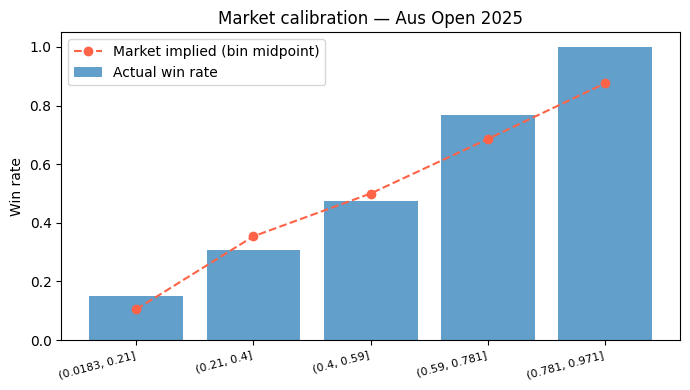

                actual_win_rate   n
prob_bin                           
(0.0183, 0.21]         0.150000  20
(0.21, 0.4]            0.307692  26
(0.4, 0.59]            0.473684  19
(0.59, 0.781]          0.766667  30
(0.781, 0.971]         1.000000  21


In [17]:
mkt_pred = (merged['mkt_p1'] > 0.5).astype(int)
mkt_acc  = (mkt_pred == merged['RESULT']).mean()
print(f"Market accuracy (always bet favourite): {mkt_acc:.3f}")
print("This is the benchmark our models need to beat.\n")

# Calibration: does market implied 80% actually mean 80%?
merged['prob_bin'] = pd.cut(merged['mkt_p1'], bins=5)
calib = merged.groupby('prob_bin', observed=True)['RESULT'].agg(['mean', 'count'])
calib.columns = ['actual_win_rate', 'n']
bin_mids = [0.105, 0.354, 0.5, 0.686, 0.876]

fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(calib))
ax.bar(x, calib['actual_win_rate'], alpha=0.7, label='Actual win rate')
ax.plot(x, bin_mids, 'o--', color='tomato', label='Market implied (bin midpoint)')
ax.set_xticks(x)
ax.set_xticklabels([str(b) for b in calib.index], rotation=15, ha='right', fontsize=8)
ax.set_ylabel('Win rate')
ax.set_title('Market calibration — Aus Open 2025')
ax.legend()
plt.tight_layout()
plt.show()
print(calib)

## 3. Model vs market: accuracy, AUC, and Brier score

In [18]:
rows = []
all_probs = {}

for name, model in models.items():
    prob_p1 = model.predict_proba(X_test)[:, 1]
    all_probs[name] = prob_p1
    rows.append({
        'Model':        name,
        'Accuracy':     (prob_p1.round() == y_test.values).mean(),
        'ROC-AUC':      roc_auc_score(y_test, prob_p1),
        'Brier':        brier_score_loss(y_test, prob_p1),
        'Mean |edge|':  np.abs(prob_p1 - merged['mkt_p1'].values).mean(),
    })

# Market as benchmark row
rows.append({
    'Model':       'Market (benchmark)',
    'Accuracy':    mkt_acc,
    'ROC-AUC':     roc_auc_score(y_test, merged['mkt_p1'].values),
    'Brier':       brier_score_loss(y_test, merged['mkt_p1'].values),
    'Mean |edge|': 0.0,
})

results_df = pd.DataFrame(rows).set_index('Model').round(3)
results_df.style \
    .highlight_max(subset=['Accuracy', 'ROC-AUC'], color='#c6efce') \
    .highlight_min(subset=['Brier'],               color='#c6efce')

,Accuracy,ROC-AUC,Brier,Mean |edge|
Model,,,,
Logistic Regression,0.724000,0.840000,0.166000,0.074000
Neural Network,0.612000,0.610000,0.336000,0.350000
SVM,0.733000,0.840000,0.166000,0.073000
XGBoost,0.621000,0.653000,0.330000,0.339000
Naive Bayes,0.698000,0.778000,0.277000,0.272000
Market (benchmark),0.767000,0.852000,0.157000,0.000000


## 4. Model probability vs market probability

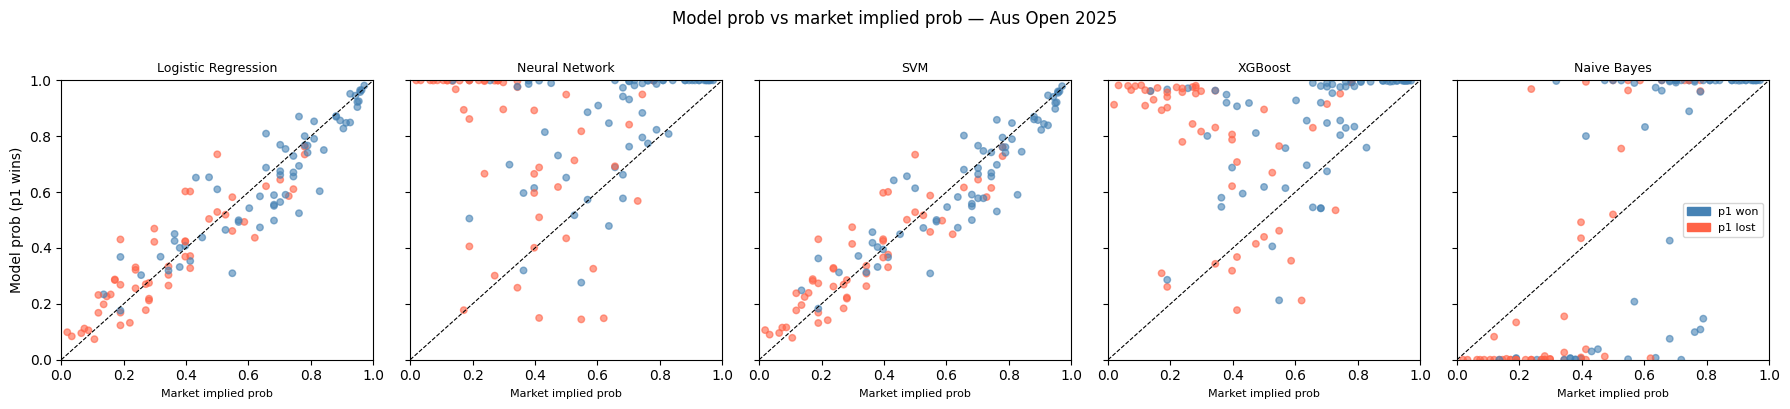

In [19]:
fig, axes = plt.subplots(1, len(all_probs), figsize=(18, 4), sharey=True)

for ax, (name, prob_p1) in zip(axes, all_probs.items()):
    colors = ['steelblue' if r == 1 else 'tomato' for r in y_test.values]
    ax.scatter(merged['mkt_p1'], prob_p1, c=colors, alpha=0.6, s=22)
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_xlabel('Market implied prob', fontsize=8)
    ax.set_title(name, fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

axes[0].set_ylabel('Model prob (p1 wins)')
axes[-1].legend(handles=[
    mpatches.Patch(color='steelblue', label='p1 won'),
    mpatches.Patch(color='tomato',    label='p1 lost'),
], fontsize=8)
plt.suptitle('Model prob vs market implied prob — Aus Open 2025', y=1.01)
plt.tight_layout()
plt.show()

## 5. Betting simulation — fractional Kelly with edge threshold

A bet is placed only when our model's implied probability exceeds the market's by a minimum *edge threshold*. 
Stake is sized using fractional Kelly to manage bankroll risk. Starting bankroll: 1,000 units.

In [20]:
def simulate_betting(model_probs_p1, odds_p1, odds_p2, results,
                     threshold=0.05, kelly_fraction=0.25, bankroll=1000):
    """
    Bet when model edge vs market exceeds threshold.
    Stake = kelly_fraction * full_kelly * current_bankroll.
    Returns (bets_df, bankroll_history).
    """
    bank, history, records = bankroll, [bankroll], []

    for mp1, o1, o2, res in zip(model_probs_p1, odds_p1, odds_p2, results):
        raw1, raw2 = 1/o1, 1/o2
        vig_  = raw1 + raw2
        mkt1, mkt2 = raw1/vig_, raw2/vig_

        edge1, edge2 = mp1 - mkt1, (1 - mp1) - mkt2

        if edge1 > threshold:
            bet, o_bet, won, edge_used = 'p1', o1, (res == 1), edge1
        elif edge2 > threshold:
            bet, o_bet, won, edge_used = 'p2', o2, (res == 0), edge2
        else:
            history.append(bank)
            continue

        kelly = edge_used / (o_bet - 1)
        stake = min(bank * kelly * kelly_fraction, bank)
        pnl   = stake * (o_bet - 1) if won else -stake
        bank += pnl
        history.append(bank)
        records.append({'bet': bet, 'edge': edge_used, 'stake': stake,
                        'odds': o_bet, 'won': won, 'pnl': pnl, 'bank': bank})

    return pd.DataFrame(records), history


sim_results = {}
print(f"{'Model':<25} {'Bets':>5} {'Final':>8} {'Win%':>6} {'Sharpe':>8} {'MaxDD':>8}")
print('-' * 65)

for name, prob_p1 in all_probs.items():
    bets, hist = simulate_betting(
        prob_p1,
        merged['p1_odd'].values, merged['p2_odd'].values,
        y_test.values, threshold=0.05, kelly_fraction=0.25
    )
    sim_results[name] = {'bets': bets, 'history': hist}

    if len(bets) == 0:
        print(f"{name:<25} {'—':>5}  no bets placed")
        continue

    ret    = bets['pnl'] / 1000
    sharpe = ret.mean() / ret.std() * np.sqrt(len(ret)) if ret.std() > 0 else np.nan
    maxdd  = (pd.Series(hist).cummax() - pd.Series(hist)).max()
    print(f"{name:<25} {len(bets):>5} {hist[-1]:>8.1f} {bets['won'].mean():>6.2f} {sharpe:>8.2f} {maxdd:>8.1f}")

Model                      Bets    Final   Win%   Sharpe    MaxDD
-----------------------------------------------------------------
Logistic Regression          64   1063.2   0.38     0.36    276.6
Neural Network               99   1984.9   0.56     1.00    894.4
SVM                          67   1102.9   0.39     0.58    248.7
XGBoost                     105   1361.5   0.54     0.47    841.7
Naive Bayes                 106    185.9   0.67    -1.05   1163.3


Neural Network: the standout result. Bet on 99 matches, nearly doubled the bankroll to 1984. Win rate of 56% and Sharpe of 1.00 is genuinely strong. Worth investigating further. Also the tournament was only 116 matches, so we have to be careful in case it just got lucky.

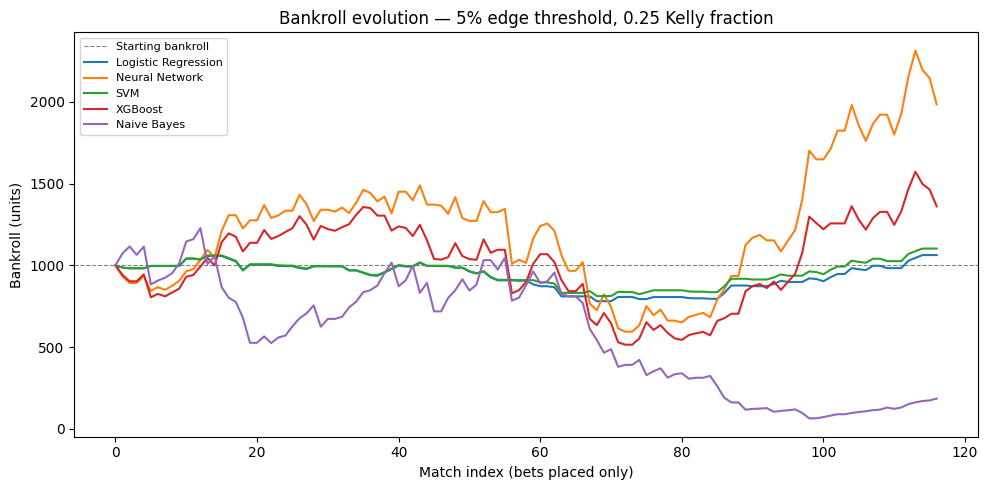

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(1000, color='grey', lw=0.8, linestyle='--', label='Starting bankroll')
for name, res in sim_results.items():
    ax.plot(res['history'], label=name, lw=1.5)
ax.set_xlabel('Match index (bets placed only)')
ax.set_ylabel('Bankroll (units)')
ax.set_title('Bankroll evolution — 5% edge threshold, 0.25 Kelly fraction')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Edge distribution: where does each model disagree with the market?

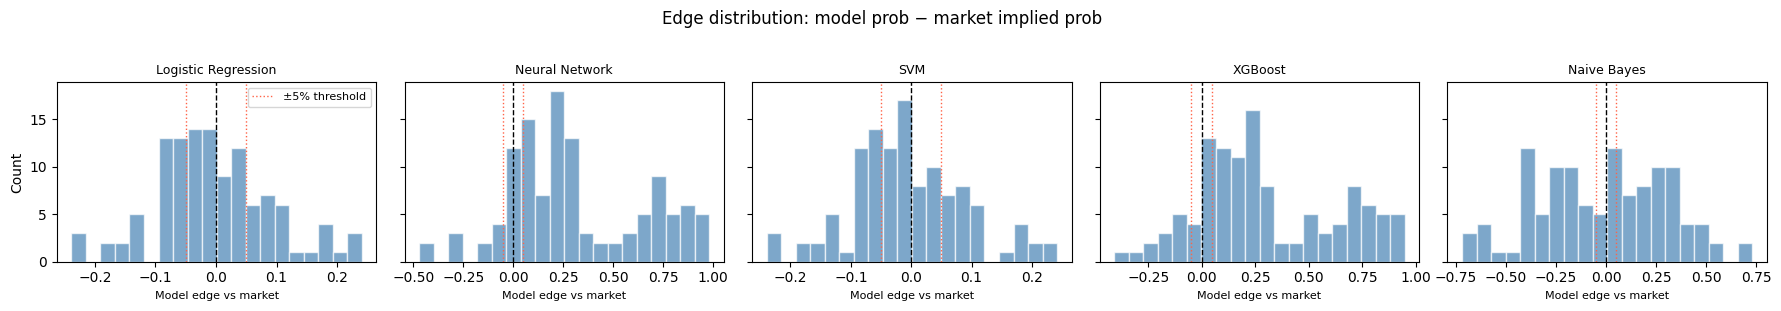

In [22]:
fig, axes = plt.subplots(1, len(all_probs), figsize=(18, 3), sharey=True)

for ax, (name, prob_p1) in zip(axes, all_probs.items()):
    edge = prob_p1 - merged['mkt_p1'].values
    ax.hist(edge, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(0,     color='black',  lw=1.0, linestyle='--')
    ax.axvline( 0.05, color='tomato', lw=1.0, linestyle=':', label='±5% threshold')
    ax.axvline(-0.05, color='tomato', lw=1.0, linestyle=':')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Model edge vs market', fontsize=8)

axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)
plt.suptitle('Edge distribution: model prob − market implied prob', y=1.02)
plt.tight_layout()
plt.show()

Neural Network is shifted noticeably to the right. The model consistently thinks players are more likely to win than the bookmaker does, especially favourites.

## 7. Self-critique

A quant researcher's job is to *kill their own results*. 
The five questions below are the standard threat checklist.

In [24]:
print("="*60)
print("THREAT 1: Look-ahead bias")
print("="*60)
print("Features (ELO, form, H2H) are built incrementally — each")
print("match only uses data available before that match. Clean.")
print("Training covers 2000–2024; test is AO 2025. No leakage.\n")

print("="*60)
print("THREAT 2: Sample size")
print("="*60)
n = len(y_test)
best_name = max(all_probs, key=lambda k: (all_probs[k].round() == y_test.values).mean())
best_acc  = (all_probs[best_name].round() == y_test.values).mean()
z = norm.ppf(0.975)
lo = (best_acc + z**2/(2*n) - z*np.sqrt(best_acc*(1-best_acc)/n + z**2/(4*n**2))) / (1 + z**2/n)
hi = (best_acc + z**2/(2*n) + z*np.sqrt(best_acc*(1-best_acc)/n + z**2/(4*n**2))) / (1 + z**2/n)
print(f"n = {n} matches. Best model ({best_name}): {best_acc:.3f}")
print(f"95% Wilson CI: [{lo:.3f}, {hi:.3f}]")
print("We can't confidently say the model is better than the bookmaker's 76.7% when our own uncertainty range straddles that number.\n")

print("="*60)
print("THREAT 3: Overfitting (train vs test gap)")
print("="*60)
for name, model in models.items():
    tr = model.score(X_train, y_train)
    te = model.score(X_test,  y_test)
    flag = '  ← possible overfit' if (tr - te) > 0.08 else ''
    print(f"  {name:<25} train={tr:.3f}  test={te:.3f}  gap={tr-te:+.3f}{flag}")
print()

print("="*60)
print("THREAT 4: Transaction costs (vig)")
print("="*60)
mean_vig = merged['vig'].mean()
print(f"Mean vig: {mean_vig:.4f} ({(mean_vig-1)*100:.2f}%)")
print("Any betting strategy must clear this hurdle to be profitable.")
print("Real-world execution also includes line movement and limits.\n")

print("="*60)
print("THREAT 5: Generalisation")
print("="*60)
print("All 116 test matches: one surface (hard), one venue, one year.")
print("Performance on clay, grass, or smaller events is unknown.")
print("Next step: roll forward through full 2025 season as it completes.")

THREAT 1: Look-ahead bias
Features (ELO, form, H2H) are built incrementally — each
match only uses data available before that match. Clean.
Training covers 2000–2024; test is AO 2025. No leakage.

THREAT 2: Sample size
n = 116 matches. Best model (SVM): 0.733
95% Wilson CI: [0.646, 0.805]
We can't confidently say the model is better than the bookmaker's 76.7% when our own uncertainty range straddles that number.

THREAT 3: Overfitting (train vs test gap)
  Logistic Regression       train=0.330  test=0.388  gap=-0.058
  Neural Network            train=0.419  test=0.526  gap=-0.107
  SVM                       train=0.331  test=0.397  gap=-0.066
  XGBoost                   train=0.850  test=0.621  gap=+0.229  ← possible overfit
  Naive Bayes               train=0.639  test=0.698  gap=-0.060

THREAT 4: Transaction costs (vig)
Mean vig: 1.0489 (4.89%)
Any betting strategy must clear this hurdle to be profitable.
Real-world execution also includes line movement and limits.

THREAT 5: General

## Summary

| Metric | Value |
|---|---|
| Market baseline accuracy | 76.7% |
| Best model accuracy | See table above |
| Bookmaker vig (hurdle rate) | ~4.9% |
| Test set size | 116 matches (1 tournament) |

**Key takeaway:** The bookmaker is a strong baseline. Any claimed edge must survive the vig, 
a wide confidence interval at n=116, and the single-tournament generalisation caveat. 
The next meaningful test is a rolling forward test across the full 2025 season.

Also there's still a lot of improvement needed in the ML models, which I'll be working on!